In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from google.colab import drive
drive.mount('/content/drive')

sns.set_style('whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Wholesale customers data - Wholesale customers data.csv")
print("Tampilkan 7 Baris Pertama Data:")
display(df.head())

print("\nInformasi Dataset:")
df.info()

Tampilkan 7 Baris Pertama Data:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


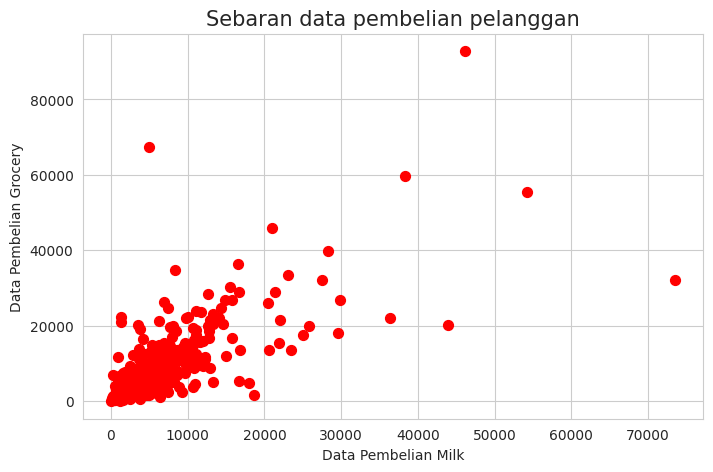

In [9]:
x = df[['Milk', 'Grocery']].values

plt.figure(figsize=(8,5))
plt.scatter(x[:,0], x[:,1], c='red', s=50)
plt.title('Sebaran data pembelian pelanggan', fontsize=15)
plt.xlabel('Data Pembelian Milk')
plt.ylabel('Data Pembelian Grocery')
plt.show()


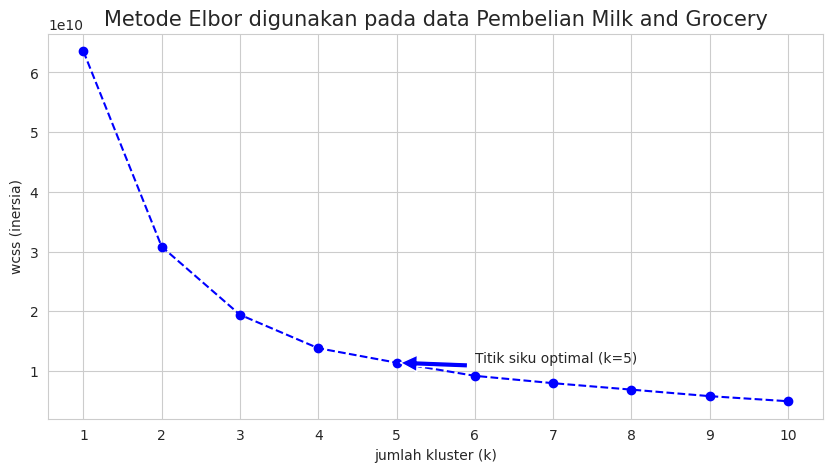

In [10]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbor digunakan pada data Pembelian Milk and Grocery', fontsize=15)
plt.xlabel('jumlah kluster (k)')
plt.ylabel('wcss (inersia)')
plt.xticks(np.arange(1,11,1))

plt.annotate('Titik siku optimal (k=5)', xy=(5, wcss[4]), xytext=(6, wcss[4] + 4000),
             arrowprops=dict(facecolor='blue', shrink=0.05))
plt.show()

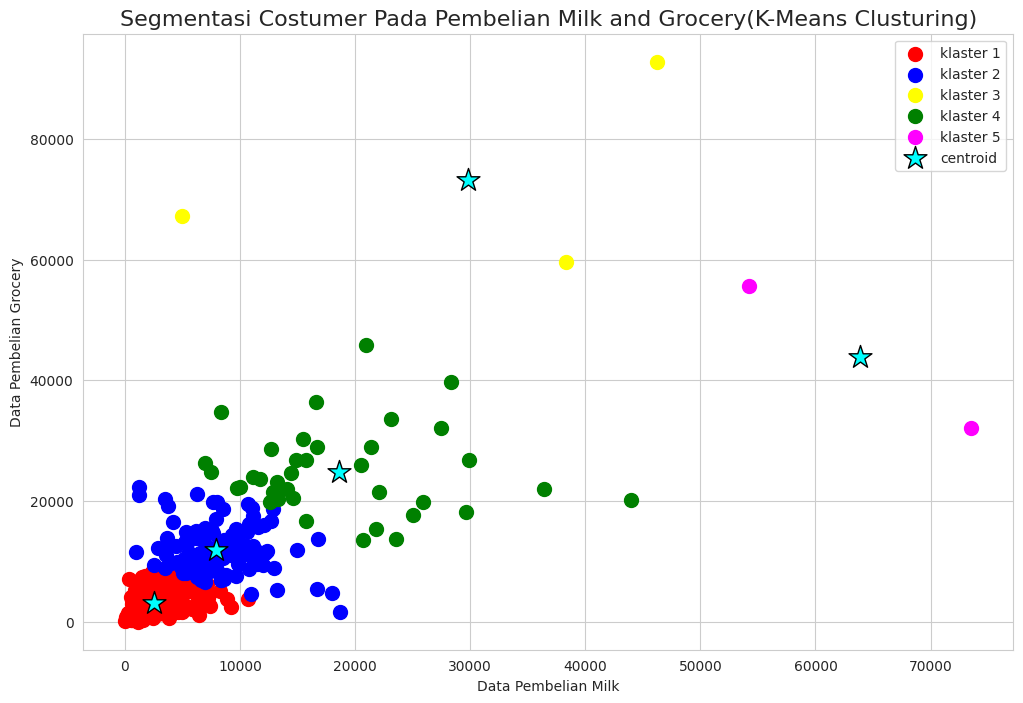

In [11]:
kmeans =KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x)

plt.figure(figsize=(12, 8))

plt.scatter(x[y_kmeans == 0,0], x[y_kmeans == 0,1], s=100, c='red', label='klaster 1')
plt.scatter(x[y_kmeans == 1,0], x[y_kmeans == 1,1], s=100, c='blue', label='klaster 2')
plt.scatter(x[y_kmeans == 2,0], x[y_kmeans == 2,1], s=100, c='yellow', label='klaster 3')
plt.scatter(x[y_kmeans == 3,0], x[y_kmeans == 3,1], s=100, c='green', label='klaster 4')
plt.scatter(x[y_kmeans == 4,0], x[y_kmeans == 4,1], s=100, c='magenta', label='klaster 5')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='cyan', marker='*', edgecolor='black', label='centroid')

plt.title('Segmentasi Costumer Pada Pembelian Milk and Grocery(K-Means Clusturing)', fontsize=16)
plt.xlabel('Data Pembelian Milk')
plt.ylabel('Data Pembelian Grocery')
plt.legend()
plt.show()